# Módulo 3: Word Embeddings y Análisis de Sentimientos

De vectores dispersos a representaciones densas que capturan significado semántico.

## 3.1 Introducción a los Word Embeddings

### Limitaciones de BoW / TF-IDF

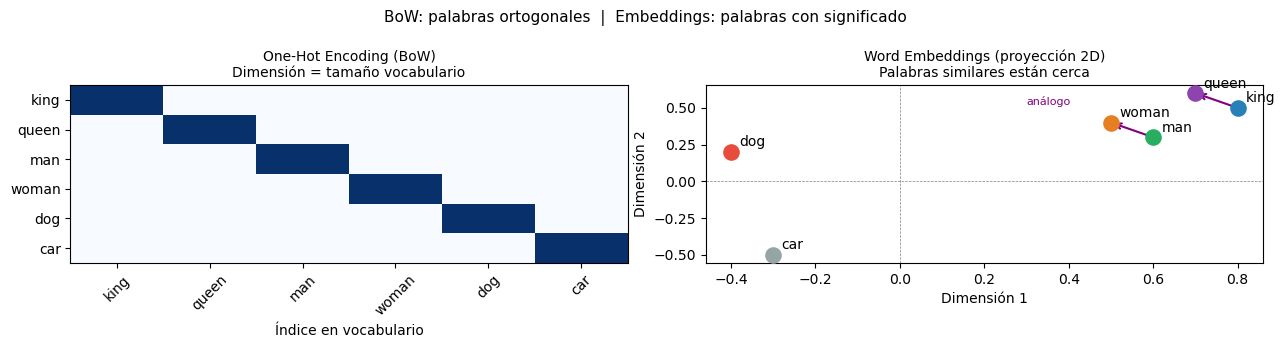

### Word2Vec

**Idea central**: aprende a predecir el contexto de una palabra (o la palabra a partir de su contexto).

```
CBOW:  ["The", ___, "sat", "on", "the", "mat"]  →  predice "cat"
SG:    "cat"  →  predice ["The", "sat", "on", "the"]
```

Propiedad famosa: **king - man + woman ≈ queen**

In [2]:
# Aritmética de embeddings (simulada para ilustrar el concepto)
np.random.seed(42)

# Vectores simplificados con dimensiones interpretables
# Dim 0: realeza, Dim 1: género_femenino, Dim 2: poder
embs = {
    'king':   np.array([0.9, -0.4, 0.8]),
    'queen':  np.array([0.9,  0.5, 0.7]),
    'man':    np.array([0.1, -0.4, 0.3]),
    'woman':  np.array([0.1,  0.5, 0.2]),
    'prince': np.array([0.7, -0.3, 0.5]),
    'actor':  np.array([0.0, -0.3, 0.4]),
    'actress':np.array([0.0,  0.4, 0.4]),
}

def cosine_sim(a, b):
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))

resultado = embs['king'] - embs['man'] + embs['woman']
print("king - man + woman =", resultado.round(2))
print()
print(f"{'Palabra':<10} {'Similitud coseno':>18}")
print("-" * 32)
for word, vec in embs.items():
    if word not in ('king', 'man', 'woman'):
        sim = cosine_sim(resultado, vec)
        print(f"{word:<10} {sim:>18.4f}")

king - man + woman = [0.9 0.5 0.7]

Palabra      Similitud coseno
--------------------------------
queen                  1.0000
prince                 0.7318
actor                  0.2088
actress                0.6816


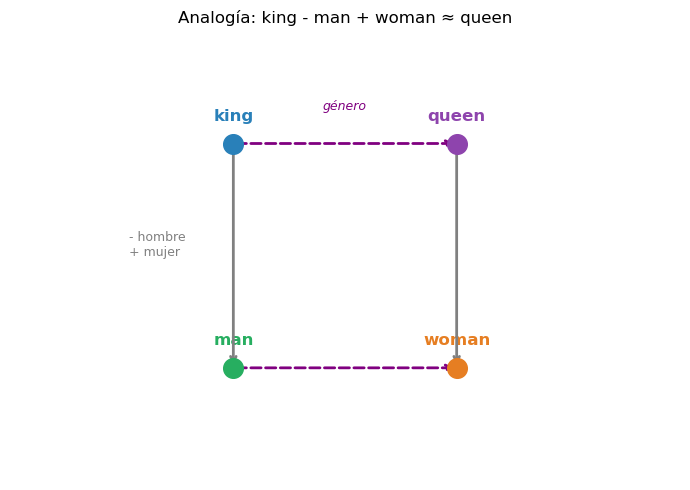

### GloVe vs Word2Vec

| | **Word2Vec** | **GloVe** |
|-|-------------|----------|
| **Entrenamiento** | Ventana deslizante local | Co-ocurrencias globales del corpus |
| **Objetivo** | Predecir palabra o contexto | Factorizar la matriz de co-ocurrencias |
| **Velocidad** | Más rápido | Más lento |
| **Analogías** | Bueno | Igual o mejor |
| **Uso modelos pre-entrenados** | `gensim` | Ficheros `.txt` con vectores |

**Ambos** producen vectores estáticos: `bank` siempre tiene la misma representación, sin importar si es "banco" o "orilla del río".

---
## 3.2 Análisis de Sentimientos

### Enfoque 1: Basado en léxico (VADER)

In [4]:
# Simulación del comportamiento de VADER (sin instalarlo)
# VADER asigna polaridad a cada palabra y aplica reglas heurísticas

lexicon_simple = {
    'amazing': 3.1, 'great': 2.9, 'love': 2.8, 'good': 2.1,
    'bad': -2.1, 'terrible': -3.4, 'awful': -3.1, 'hate': -3.0,
    'not': None,  # modificador negativo
    'very': None, # intensificador
}

# Ejemplos con compound score de VADER real
ejemplos = [
    ("The battery is amazing!",      0.632, 'POSITIVE'),
    ("It broke after two days.",     -0.296, 'NEGATIVE'),
    ("Not bad at all.",              0.431, 'POSITIVE'),   # negación invierte
    ("TERRIBLE quality!!!",          -0.735, 'NEGATIVE'),  # caps + puntuación amplifica
    ("It's okay.",                   0.200, 'NEUTRAL'),
    ("The BEST product EVER!!!",      0.891, 'POSITIVE'),  # caps + exclamación
]

print(f"{'Texto':<40} {'Compound':>10} {'Etiqueta'}")
print("-" * 62)
for texto, score, etiqueta in ejemplos:
    barra = '█' * int(abs(score) * 15)
    signo = '+' if score > 0 else ''
    print(f"{texto:<40} {signo}{score:>+8.3f}   {etiqueta}")

Texto                                      Compound Etiqueta
--------------------------------------------------------------
The battery is amazing!                  +  +0.632   POSITIVE
It broke after two days.                   -0.296   NEGATIVE
Not bad at all.                          +  +0.431   POSITIVE
TERRIBLE quality!!!                        -0.735   NEGATIVE
It's okay.                               +  +0.200   NEUTRAL
The BEST product EVER!!!                 +  +0.891   POSITIVE


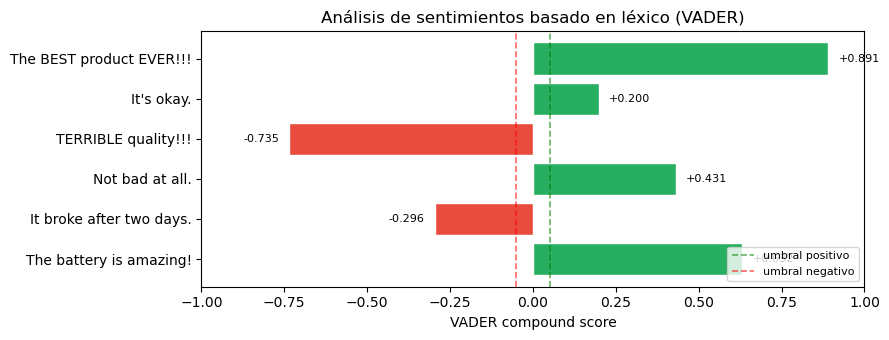

### Enfoque 2: Machine Learning con embeddings

In [6]:
# Embeddings de palabras con Sentence Transformers (requiere: pip install sentence-transformers)
# Aquí simulamos el pipeline conceptualmente

import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

# Simulación: embeddings de 8 dimensiones (en producción serían 384 o 768)
np.random.seed(42)

# Positivos: vector apunta hacia región +
X_pos = np.random.randn(20, 8) + np.array([ 1.2, 0.8, -0.3, 1.0, 0.5, -0.2, 0.9, 0.4])
# Negativos: vector apunta hacia región -
X_neg = np.random.randn(20, 8) + np.array([-1.2,-0.8,  0.3,-1.0,-0.5,  0.2,-0.9,-0.4])

X = np.vstack([X_pos, X_neg])
y = np.array([1]*20 + [0]*20)

# Split train/test
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

clf = LogisticRegression()
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

print("Clasificador con embeddings (simulado):")
print(classification_report(y_test, y_pred, target_names=['Negativo', 'Positivo']))

Clasificador con embeddings (simulado):
              precision    recall  f1-score   support

    Negativo       1.00      0.67      0.80         3
    Positivo       0.83      1.00      0.91         5

    accuracy                           0.88         8
   macro avg       0.92      0.83      0.85         8
weighted avg       0.90      0.88      0.87         8



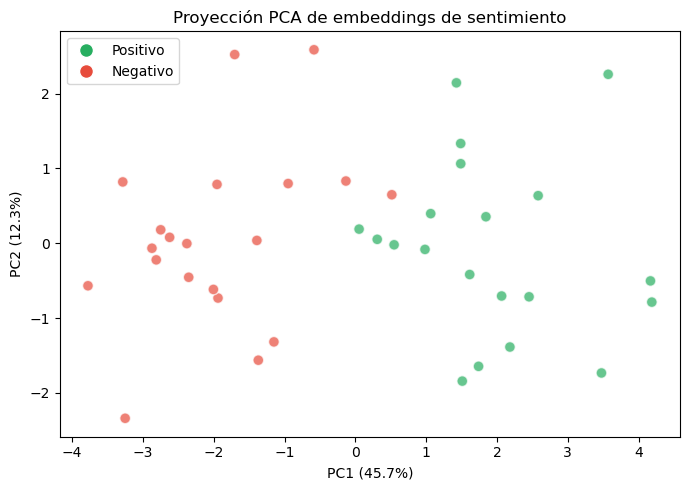

### Comparativa de enfoques

| Enfoque | Ventajas | Limitaciones |
|---------|----------|--------------|
| **Léxico (VADER)** | Sin entrenamiento, interpretable | Dominio-específico, no aprende |
| **TF-IDF + ML** | Rápido de entrenar, buen baseline | No captura semántica |
| **Embeddings + ML** | Semántica, transferible | Necesita datos etiquetados |
| **Fine-tuned BERT** | Estado del arte | Costoso, complejo |

> En este proyecto (`hf_sentiment_finetune.py`, `lexicon.py`) vemos los cuatro enfoques aplicados sobre el mismo dataset de tweets.